In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       8465 non-null   str    
 1   Open       8465 non-null   float64
 2   High       8465 non-null   float64
 3   Low        8465 non-null   float64
 4   Close      8465 non-null   float64
 5   Volume     8465 non-null   int64  
 6   Adj Close  8465 non-null   float64
dtypes: float64(5), int64(1), str(1)
memory usage: 463.1 KB


In [4]:
df.head(30)

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52
5,2014-06-30,92.10,93.73,92.09,92.93,49482300,92.93
6,2014-06-27,90.82,92.00,90.77,91.98,64006800,91.98
7,2014-06-26,90.37,91.05,89.80,90.90,32595800,90.90
8,2014-06-25,90.21,90.70,89.65,90.36,36852200,90.36
9,2014-06-24,90.75,91.74,90.19,90.28,38988300,90.28


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df.head(1)

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.8,93.92,95.35,65130000,95.35


In [6]:
df.set_index('Date', inplace=True)

In [7]:
df.index.duplicated().sum()

np.int64(0)

In [8]:
df.sort_values(by='Date', inplace=True,ascending=True)

In [9]:
#step 9
df.loc[df.index.is_month_end]

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-31,34.25,34.25,34.13,34.13,8937600,0.53
1981-03-31,24.75,24.75,24.50,24.50,3998400,0.38
1981-04-30,28.38,28.62,28.38,28.38,3152800,0.44
1981-06-30,26.13,26.13,26.00,26.00,8976800,0.41
1981-07-31,25.00,25.12,25.00,25.00,2738400,0.39
...,...,...,...,...,...,...
2014-01-31,495.18,501.53,493.55,500.60,116199300,70.69
2014-02-28,529.08,532.75,522.12,526.24,92992200,74.76
2014-03-31,539.23,540.81,535.93,536.74,42167300,76.25


In [10]:
#step 10
abs((df.index[0] - df.index[len(df.index)-1]).days)

12261

In [11]:
df.groupby(pd.Grouper(freq='ME')).count().count().max()

np.int64(404)

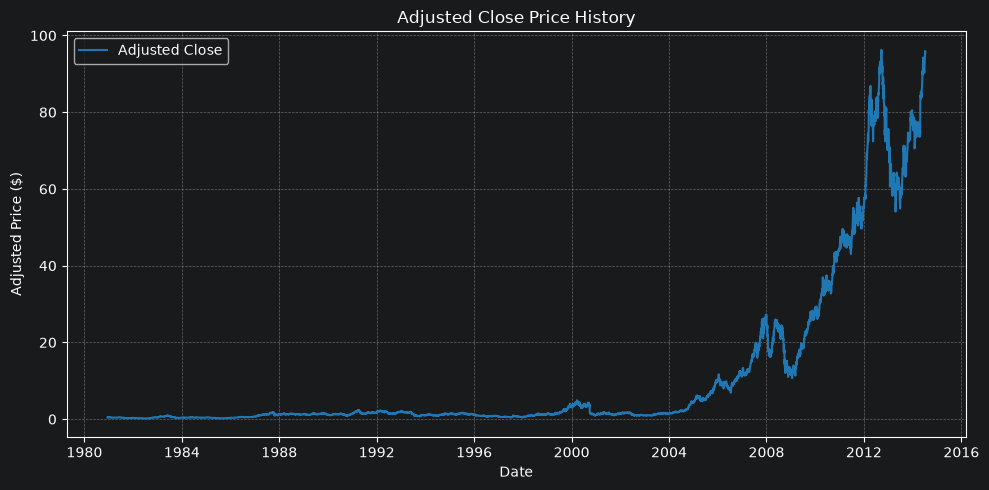

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Adj Close'], label='Adjusted Close', color='#1f77b4', linewidth=1.5)

plt.title('Adjusted Close Price History')
plt.xlabel('Date')
plt.ylabel('Adjusted Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
#BONUS
#which month had the highest volume
df.groupby(pd.Grouper(freq='ME')).sum()['Volume'].idxmax()

Timestamp('2008-10-31 00:00:00')